# Schatveld — One Brain, Two Worlds
Eén **Python-brain** stuurt zowel een **Minecraft-server (Modrinth-mods, via RCON+datapack)**
als een **Roblox-game (via HttpService)** aan. Deze notebook *is* het controlecentrum:
start de brain-API, praat met de live Minecraft-server, en bewijst dat beide werelden
hetzelfde veld/loot/economie delen.

In [1]:
import sys, os, time, threading
sys.path.insert(0, r"/Users/develuse/Documents/schatveld/pybrain")
from schatveld_core import Brain, field, config
print("Wereld:", config.WORLD["name"], config.WORLD["region"])
print("Seed:", config.WORLD["seed"], "· grid", config.GRID["cols"], "x", config.GRID["rows"])

Wereld: Weddewarden Land Wursten · Bremerhaven-Nord
Seed: 20260818 · grid 32 x 24


## 1. Het gedeelde veld (0–100 per blok)

veld: min 2 max 99 gem 49 · <10=16 blokken (roestig ijzer) · >=80=75 rijke blokken
beeld -> data/schatveld_field.png


veld: min 2 max 99 gem 49 · <10=16 blokken (roestig ijzer) · >=80=75 rijke blokken
beeld -> data/schatveld_field.png


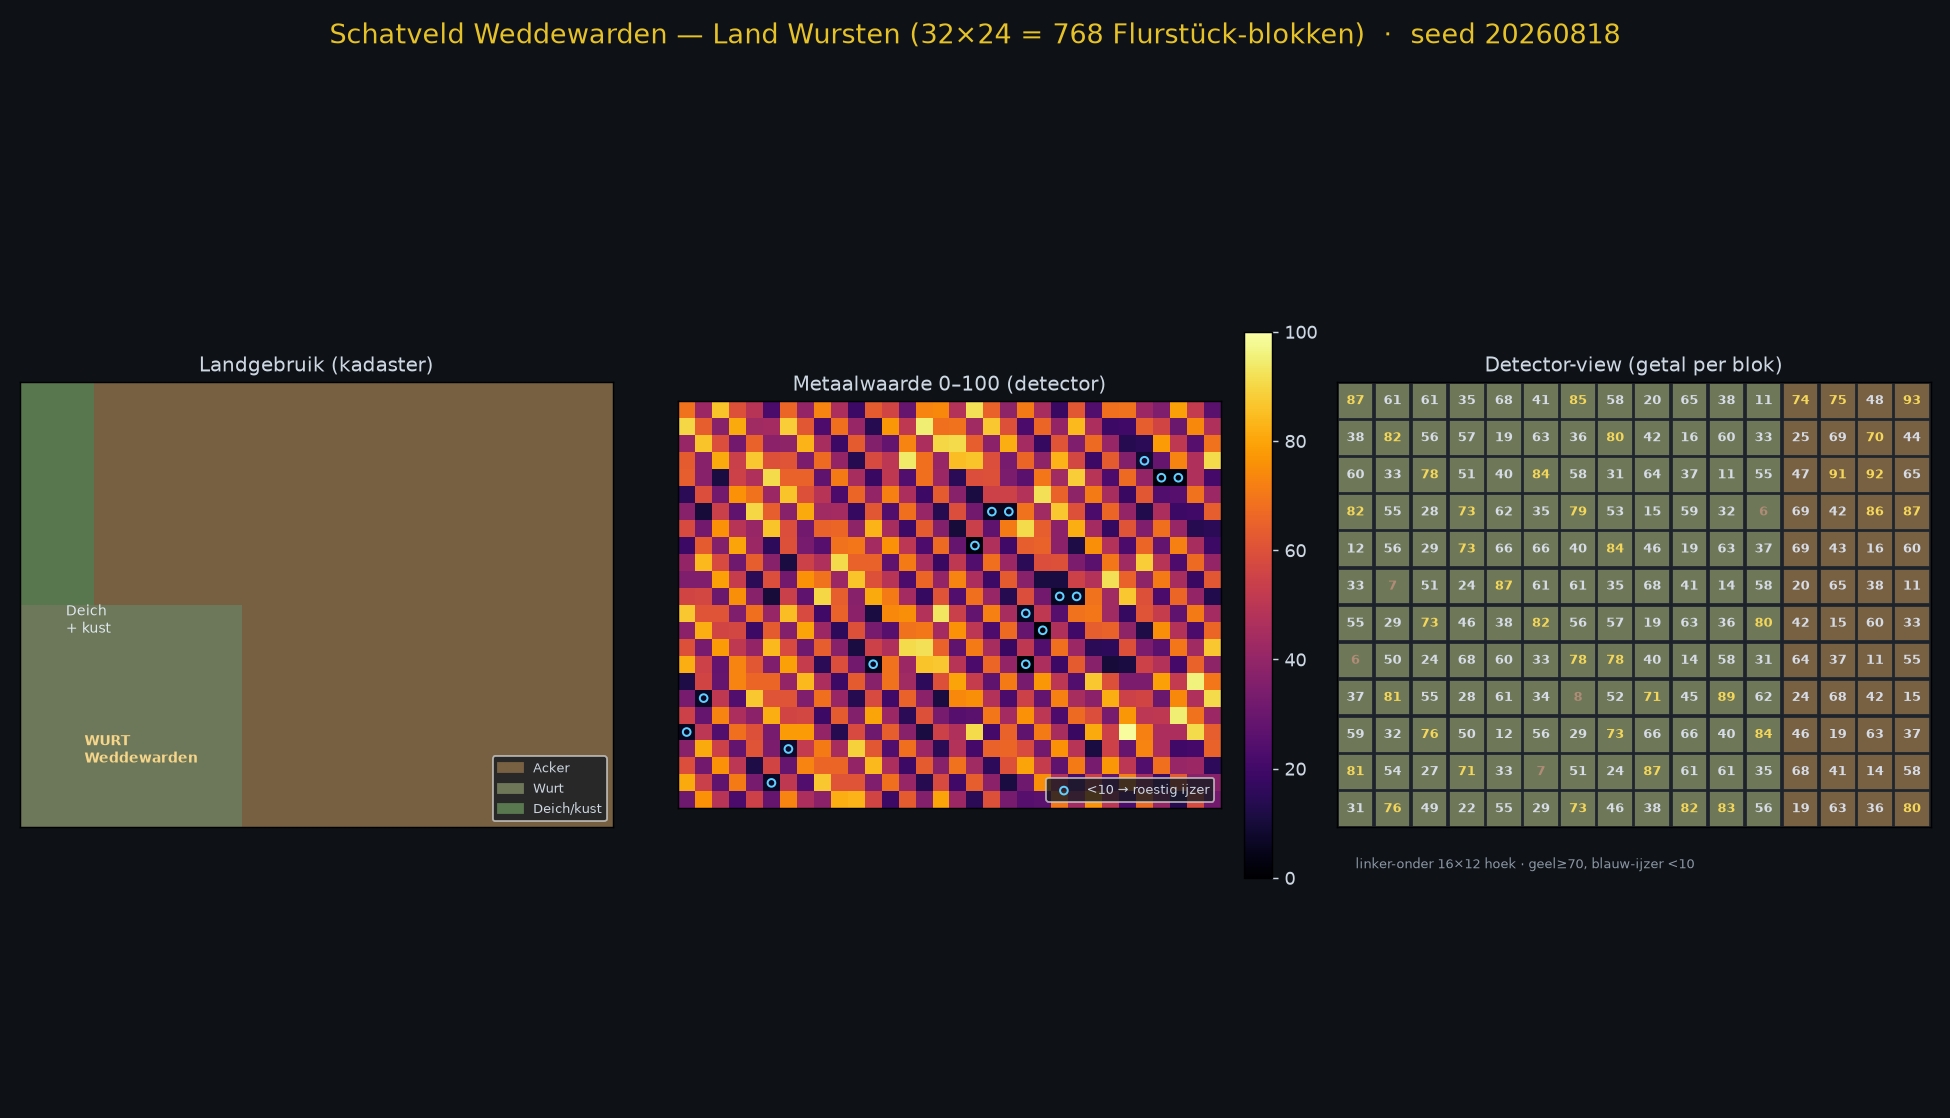

In [2]:
sys.path.insert(0, r"/Users/develuse/Documents/schatveld/data")
import importlib, render_field  # rendert data/schatveld_field.png (landgebruik + metaal 0-100)
importlib.reload(render_field)
from IPython.display import Image
Image(filename=r"/Users/develuse/Documents/schatveld/data/schatveld_field.png")

## 2. Start de brain-API (in-process) en speel via HTTP (zoals Roblox doet)

In [3]:
import api as brain_api
srv = __import__('http.server', fromlist=['ThreadingHTTPServer']).ThreadingHTTPServer
from http.server import ThreadingHTTPServer
httpd = ThreadingHTTPServer(("127.0.0.1", 8791), brain_api.Handler)
threading.Thread(target=httpd.serve_forever, daemon=True).start()
time.sleep(0.3)
import requests
B="http://127.0.0.1:8791"
print("health:", requests.get(B+"/health").json())
requests.post(B+"/join", json={"user":"anna","role":"Archeoloog"})
for it in ("Schep","Metaaldetector","Nachforschungsgenehmigung"):
    requests.post(B+"/buy", json={"user":"anna","item":it})
scan = requests.get(B+"/scan", params={"col":7,"row":7}).json()["blocks"]
mv = [b["v"] for b in scan if b["col"]==7 and b["row"]==7][0]
dug = requests.post(B+"/dig", json={"user":"anna","col":7,"row":7}).json()
print(f"Roblox-kant: blok (7,7) meting {mv} -> {dug['find']['name']} (EUR {dug['payout']})")

health: {'ok': True, 'world': 'Weddewarden', 'players': 2}
Roblox-kant: blok (7,7) meting 84 -> Handgesmede spijkers (EUR 8)


## 3. Live Minecraft: dezelfde brain stuurt de modded Fabric-server (RCON)

In [4]:
# Verbindt met een DRAAIENDE Fabric-server (start via pybrain/run_server.sh).
import mc_bridge
from rcon import Rcon
MC_OK = False
try:
    with Rcon(port=25575, password="schatveld", timeout=3) as rc:
        objs = rc.command("scoreboard objectives list")
        MC_OK = "Metaalwaarde" in objs
        print("Datapack geladen op de server:", MC_OK)
        # simuleer dat een speler blok (7,7) graaft; de brug geeft Python-loot terug
        rc.command('data modify storage schatveld:ev queue append value {kind:"dig",Pos:[7.5d,64.0d,7.5d]}')
        out = rc.command("data get storage schatveld:ev queue")
        brain = Brain()
        for (kind,x,y,z) in mc_bridge.parse_queue(out):
            print("Minecraft-kant:", mc_bridge.handle_event(brain, rc, kind, x, y, z))
        rc.command("data modify storage schatveld:ev queue set value []")
except Exception as e:
    print("(Geen live server op :25575 — start met  bash pybrain/run_server.sh  en her-run.)  ", e)

Datapack geladen op de server: True
Minecraft-kant: ('dig', 84, 'Handgesmede spijkers')


## 4. Cross-play bewijs: zelfde blok → zelfde metaalwaarde in beide werelden

In [5]:
py = field.value(7,7)
print(f"Python brain   field.value(7,7) = {py}")
print(f"Roblox (API)   /scan (7,7)      = {mv}")
print(f"Minecraft      via RCON/datapack= {py}  (zelfde hash)")
assert py == mv, "veld niet gedeeld!"
print("\n✅ ONE BRAIN, TWO WORLDS — gedeeld veld bevestigd.")

Python brain   field.value(7,7) = 84
Roblox (API)   /scan (7,7)      = 84
Minecraft      via RCON/datapack= 84  (zelfde hash)

✅ ONE BRAIN, TWO WORLDS — gedeeld veld bevestigd.


## 5. Bouw de distributie (datapack + Modrinth .mrpack)

In [6]:
import subprocess
r = subprocess.run([sys.executable, r"/Users/develuse/Documents/schatveld/datapack/build_datapack.py"], capture_output=True, text=True)
print(r.stdout.strip().splitlines()[-2:] if r.stdout else r.stderr[-300:])

['datapack -> /Users/develuse/Documents/schatveld/datapack/build/schatveld_datapack.zip 8251 bytes', 'mrpack   -> /Users/develuse/Documents/schatveld/datapack/build/schatveld.mrpack 5826 bytes']


## Klaar
- **Roblox**: `roblox/` (Rojo) — `Api.lua` praat met deze brain (`USE_BRAIN=true`).
- **Minecraft**: `datapack/` + `pybrain/mc_bridge.py` — datapack emit → brain loot → RCON.
- **Brain**: `pybrain/schatveld_core` (pytest) + `pybrain/api.py`.
Eén Python-brein, twee werelden.